# Column — simple example

Section + materials, interaction diagram, P-M-M volume, and transverse-reinforcement design before and after demands. Internal units: MPa, mm, kN.

In [1]:
import matplotlib.pyplot as plt

from design import (
    Concrete, Steel, Bar, RectangularSection, Column,
    to_internal, units_from,
)
from design.columns.column import ColumnDemands
from design.sections.reinforcement import RebarLayout, perimeter_bars



## Materials and section — the CANDIDATE

The block below builds a column from scalar inputs in one call. The reinforcement
you pass here is the **candidate** you want to check. Pass full detailing
to evaluate it; leave the transverse fields out to let `design()` propose them later.


In [2]:
# Materials
concrete = Concrete(fc=28)
steel    = Steel(fy=420, grade=60)

# === EDIT — section + reinforcement candidate ===
b, h, clear_cover = 500, 500, 25
n_x, n_y          = 4, 4
db_long           = 22

db_stirrup        = 10
n_legs_x          = 3        # legs ∥ X (resist Vy)
n_legs_y          = 3        # legs ∥ Y (resist Vx)
s_stirrup         = 100      # mm
# ====================================================

column = Column.rectangular(
    b=b, h=h, clear_cover=clear_cover,
    concrete=concrete, steel=steel,
    n_x=n_x, n_y=n_y, db_long=db_long,
    db_stirrup=db_stirrup,
    n_legs_x=n_legs_x, n_legs_y=n_legs_y,
    s_stirrup=s_stirrup,
    lu=3000.0, seismic=True, hx=200,
    label='Col-Simple',
)
column.run()


Column(label='Col-Simple', section=400×800 mm, fc=21 MPa, units=Tonf_m_C, run=yes)

## Section view

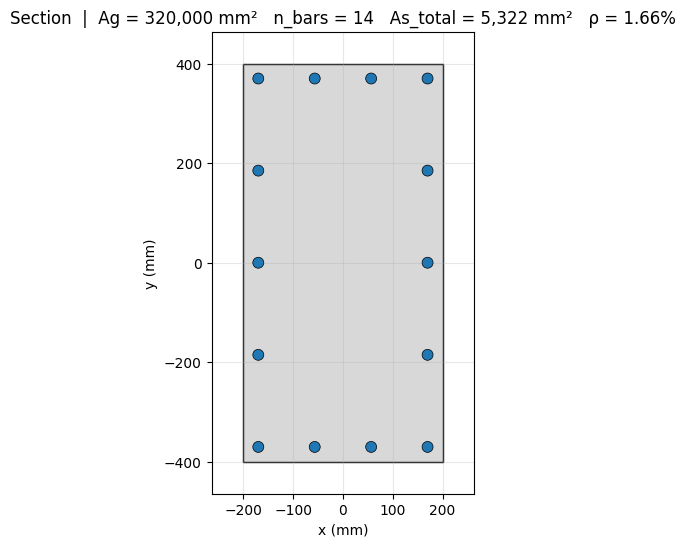

In [3]:
column.plot.section()
plt.show()

## Interaction diagram (θ = 0°)

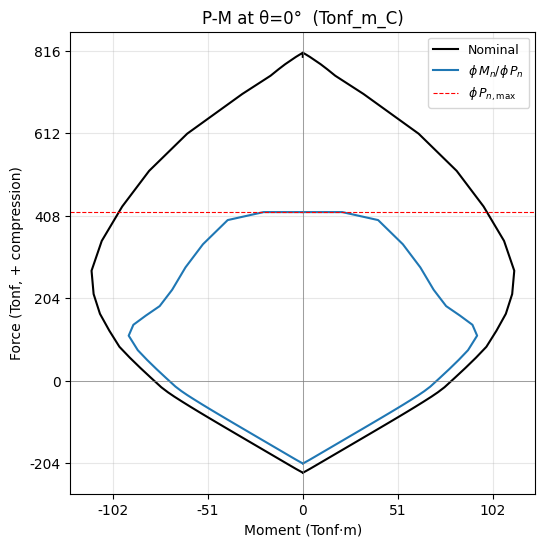

In [4]:
column.plot.pm(angle=0)
plt.show()

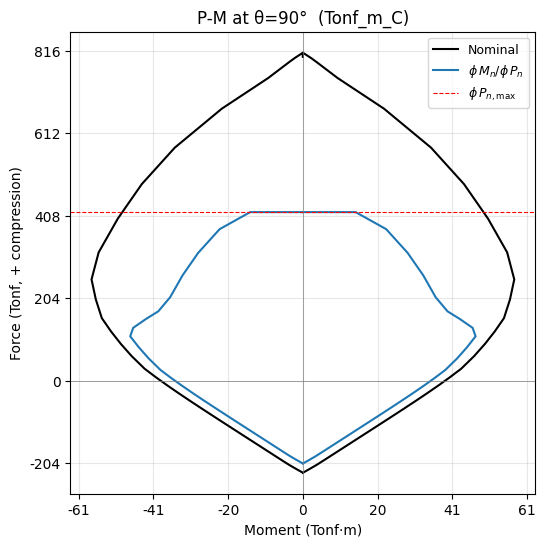

In [5]:
column.plot.pm(angle=90)
plt.show()

In [6]:
diag0 = column.surface[0]         # diagram at θ=0
diag90 = column.surface[90]       # diagram at θ=90
print(f'max phi_Mn @ 0°  = {max(diag0.phi_Mn):.1f} kN·m (Mxx)')
print(f'max phi_Mn @ 90° = {max(diag90.phi_Mn):.1f} kN·m (Myy)')

max phi_Mn @ 0°  = 916.5 kN·m (Mxx)
max phi_Mn @ 90° = 462.2 kN·m (Myy)


## P-M-M volume

In [7]:
results = column.design()

for label in ['minimum', 'capacity', 'envelope']:
    p = getattr(results, label)
    print(f'--- {label.upper()} ---')
    print(f'  Hoop          : φ{p.db_hoop:.0f}  legs=({p.n_legs_x},{p.n_legs_y})  s={p.spacing_confined:.0f} mm')
    print(f'  φVn (X / Y)   : {p.phi_Vn_x:.0f} / {p.phi_Vn_y:.0f} kN   (capacity of the proposed transverse steel)')
    print(f'  Mpr           : {p.Mpr_top:.0f} kN·m   →   Ve_capacity = {p.Ve_capacity:.0f} kN')
    print(f'  Ve/φVn (X/Y)  : {p.ratio_Ve_over_phiVn_x:.2f} / {p.ratio_Ve_over_phiVn_y:.2f}')
    print()

# Apply the envelope reinforcement to the column
column = column.apply(results.envelope)
print(f'col.phi_Vn after apply = {column.phi_Vn:.0f} kN')


--- MINIMUM ---
  Hoop          : φ12  legs=(2,4)  s=100 mm
  φVn (X / Y)   : 681 / 681 kN   (capacity of the proposed transverse steel)
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve/φVn (X/Y)  : 0.61 / 1.20

--- CAPACITY ---
  Hoop          : φ12  legs=(3,4)  s=100 mm
  φVn (X / Y)   : 681 / 938 kN   (capacity of the proposed transverse steel)
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve/φVn (X/Y)  : 0.61 / 0.87

--- ENVELOPE ---
  Hoop          : φ12  legs=(3,4)  s=100 mm
  φVn (X / Y)   : 681 / 938 kN   (capacity of the proposed transverse steel)
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve/φVn (X/Y)  : 0.61 / 0.87

col.phi_Vn after apply = 938 kN


## Transverse reinforcement — without demands (code minimums)

In [8]:
# # Demands as you would read them from a force tracker — code 9 (N, mm).
# Pu_input  = 2_500_000        # N
# Mux_input = 200_000_000      # N·mm
# Muy_input = 120_000_000      # N·mm
# Vux_input = 150_000          # N

# # Convert to internal (kN, kN·m). One helper, four kinds: force / moment.
# Pu  = to_internal('force',  Pu_input,  units=INPUT_UNITS)
# Mux = to_internal('moment', Mux_input, units=INPUT_UNITS)
# Muy = to_internal('moment', Muy_input, units=INPUT_UNITS)
# Vux = to_internal('force',  Vux_input, units=INPUT_UNITS)

# demands = ColumnDemands(Pu=Pu, Mux=Mux, Muy=Muy, Vux=Vux)

# chk = column.check(demands)
# print(f'ratio PMM   = {chk.ratio_pmm:.3f}')
# print(f'ratio shear = {chk.ratio_shear:.3f}')
# print(f'passed      = {chk.passed}')

## Demands

In [9]:
demands = ColumnDemands(
    Pu=2500.0,
    Mux=200.0,
    Muy=120.0,
    Vux=150.0,
)

chk = column.check(demands)
print(f'ratio PMM   = {chk.ratio_pmm:.3f}')
print(f'ratio shear = {chk.ratio_shear:.3f}')
print(f'passed      = {chk.passed}')

ratio PMM   = 0.416
ratio shear = 0.160
passed      = True


## Transverse reinforcement — with demands

In [10]:
results = column.design(demands)

for label in ['minimum', 'demand', 'capacity', 'envelope']:
    p = getattr(results, label)
    if p is None: continue
    print(f'--- {label.upper()} ---')
    print(f'  Hoop          : φ{p.db_hoop:.0f}  legs=({p.n_legs_x},{p.n_legs_y})  s={p.spacing_confined:.0f} mm')
    print(f'  φVn (X / Y)   : {p.phi_Vn_x:.0f} / {p.phi_Vn_y:.0f} kN')
    print(f'  Mpr           : {p.Mpr_top:.0f} kN·m   →   Ve_capacity = {p.Ve_capacity:.0f} kN')
    if p.Ve_used is not None:
        print(f'  Ve_used       : {p.Ve_used:.0f} kN   (capped by Ωo·Vu if applicable)')
    print(f'  Ve/φVn (X/Y)  : {p.ratio_Ve_over_phiVn_x:.2f} / {p.ratio_Ve_over_phiVn_y:.2f}')
    print()

column = column.apply(results.envelope)
print(f'col.phi_Vn after apply = {column.phi_Vn:.0f} kN')


--- MINIMUM ---
  Hoop          : φ12  legs=(2,4)  s=100 mm
  φVn (X / Y)   : 681 / 681 kN
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve/φVn (X/Y)  : 0.61 / 1.20

--- DEMAND ---
  Hoop          : φ12  legs=(2,4)  s=100 mm
  φVn (X / Y)   : 681 / 681 kN
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve/φVn (X/Y)  : 0.61 / 1.20

--- CAPACITY ---
  Hoop          : φ12  legs=(3,4)  s=100 mm
  φVn (X / Y)   : 681 / 938 kN
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve_used       : 817 kN   (capped by Ωo·Vu if applicable)
  Ve/φVn (X/Y)  : 0.61 / 0.87

--- ENVELOPE ---
  Hoop          : φ12  legs=(3,4)  s=100 mm
  φVn (X / Y)   : 681 / 938 kN
  Mpr           : 1226 kN·m   →   Ve_capacity = 817 kN
  Ve_used       : 817 kN   (capped by Ωo·Vu if applicable)
  Ve/φVn (X/Y)  : 0.61 / 0.87

col.phi_Vn after apply = 938 kN


## Optimize — ranked alternatives by steel quantity

`column.run_optimize(demands)` enumerates every feasible `(db_hoop, n_legs_x, n_legs_y)` combination from the bar schedule and the physical bar-count limit, computes the **kg of steel per m³ of concrete** over a 1 m slice of the confined region, and ranks them. The lightest entry is the optimum.

In [11]:
alts = column.run_optimize(demands)

print(f'{"rank":>4} {"db":>4} {"legs_x":>6} {"legs_y":>6} '
      f'{"ρ_trans":>11} {"ρ_long":>11} {"ρ_total":>11}  baseline')
print(f'{"":>4} {"":>4} {"":>6} {"":>6} '
      f'{"(kg/m³)":>11} {"(kg/m³)":>11} {"(kg/m³)":>11}')
print('-' * 75)
for i, a in enumerate(alts, 1):
    mark = ' ←' if a.is_baseline else ''
    print(f'{i:>4} φ{a.db_hoop:>3.0f} {a.n_legs_x:>6d} {a.n_legs_y:>6d}'
          f' {a.rho_transverse:>11.1f} {a.rho_longitudinal:>11.1f} {a.rho_total:>11.1f}'
          f' {str(a.is_baseline):>8}{mark}')

# Adopt the lightest
best = alts[0]
column = column.apply(best.proposal)
print()
print(f'Adopted: φ{best.db_hoop:.0f}, legs=({best.n_legs_x},{best.n_legs_y}), '
      f's={best.proposal.spacing_confined:.0f} mm, ρ_total = {best.rho_total:.1f} kg/m³')
print(f'col.phi_Vn = {column.phi_Vn:.0f} kN')

rank   db legs_x legs_y     ρ_trans      ρ_long     ρ_total  baseline
                            (kg/m³)     (kg/m³)     (kg/m³)
---------------------------------------------------------------------------
   1 φ 12      2      4       102.7       130.6       233.2    False
   2 φ 12      3      4       112.4       130.6       242.9     True ←
   3 φ 12      4      4       122.1       130.6       252.6    False
   4 φ 12      5      4       131.8       130.6       262.3    False
   5 φ 16      2      4       182.5       130.6       313.0    False
   6 φ 16      3      4       199.8       130.6       330.3    False
   7 φ 16      4      4       217.0       130.6       347.6    False
   8 φ 16      5      4       234.3       130.6       364.8    False

Adopted: φ12, legs=(2,4), s=100 mm, ρ_total = 233.2 kg/m³
col.phi_Vn = 681 kN
